In [ ]:
# Mount google drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Paths of directories

drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc"
code_data_path = f"{root_path}/code-data"

dataset_path = f"{code_data_path}/dataset"
current_path = f"{code_data_path}/training/2d_material"
saved_models_path = f"{code_data_path}/training/saved_models"


In [ ]:
# Paths of files

best_params_path = f"{saved_models_path}/mlp_2d_material_solvent_params.json"
best_model_path = f"{saved_models_path}/mlp_2d_material_solvent_model.pth"
training_loss_path = f"{saved_models_path}/mlp_2d_material_solvent_training_loss.json"
scaler_path = f"{saved_models_path}/mlp_2d_material_solvent_scaler.pkl"

In [ ]:
import sys

sys.path.append(f"{drive_path}/master/shared_code")
from my_torch import MLP, to_tensor, find_best_threshold

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load input dataset

mx_solvent_dataset = pd.read_pickle(f"{dataset_path}/dataset_mx_solvent_hsp_rename_mx_features_to_2d_material_features.pkl")

print(mx_solvent_dataset.shape)
mx_solvent_dataset.head()

(997, 65)


,mx,label,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,373.2,760.0,oxidane,True,False,False
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,351.5,760.0,ethanol,True,False,False
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,337.8,760.0,methanol,True,False,False
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,329.3,760.0,propan-2-one,True,False,False
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,354.8,760.0,acetonitrile,True,False,False


In [ ]:
# Prepare X, y datasets

df_mx_solvent = mx_solvent_dataset.drop(columns=['mx', 'inchikey', 'solvent']).astype(float)

X_mx_solvent = df_mx_solvent.drop(columns=["label"])
y_mx_solvent = df_mx_solvent["label"]

X_mx_solvent_labeled = X_mx_solvent[y_mx_solvent != 0]
y_mx_solvent_labeled = y_mx_solvent[y_mx_solvent != 0]
y_mx_solvent_labeled = np.where(y_mx_solvent_labeled == -1, 0, y_mx_solvent_labeled)

X_mx_solvent_unlabeled = X_mx_solvent[y_mx_solvent == 0]

print("Shape of labeled/unlabeled feature dataset:", X_mx_solvent.shape)
print("Shape of labeled/unlabeled target dataset:", y_mx_solvent.shape)
print("Shape of labeled feature dataset:", X_mx_solvent_labeled.shape)
print("Shape of labeled target dataset:", y_mx_solvent_labeled.shape)
print("Shape of unlabeled feature dataset:", X_mx_solvent_unlabeled.shape)

Shape of labeled/unlabeled feature dataset: (997, 61)
Shape of labeled/unlabeled target dataset: (997,)
Shape of labeled feature dataset: (83, 61)
Shape of labeled target dataset: (83,)
Shape of unlabeled feature dataset: (914, 61)


In [ ]:
x_unlabeled = mx_solvent_dataset[y_mx_solvent == 0]

In [ ]:
# Scale

from sklearn.preprocessing import StandardScaler

def scale_dataset(df, scaler):

    # Columns from old dataset (used during scaler.fit)
    common_cols = scaler.feature_names_in_

    # Columns in MXene dataset
    mx_cols = df.columns

    # 1. Extract common features in the same order as old scaler
    df_common = df[common_cols]

    # 2. Scale using pretrained scaler
    common_scaled = scaler_old.transform(df_common)

    # 3. Get the new one-hot columns (only in MXene-solvent dataset, unscaled)
    new_cols = [c for c in mx_cols if c not in common_cols]
    df_onehot = df[new_cols]

    # 4. Concatenate back
    new_scaled = np.hstack([common_scaled, df_onehot.values])

    return new_scaled


In [ ]:
# Labeled and unlabeled scaled datasets

import joblib

scaler_old = joblib.load(scaler_path)

X_mx_solvent_labeled_scaled = scale_dataset(X_mx_solvent_labeled, scaler_old)
X_mx_solvent_unlabeled_scaled = scale_dataset(X_mx_solvent_unlabeled, scaler_old)

In [ ]:
# Load hyperparameter

import json

with open(best_params_path, "r") as f:
    pretrained_params = json.load(f)

print("Loaded pretrained params:", pretrained_params)

Loaded pretrained params: {'input_dim': 58, 'hidden_dim': 256, 'dropout': 0.32062674364635424, 'output_dim': 1, 'batch_size': 16, 'lr': 0.00182400525554883, 'best_f1': 0.8202487580045125}


In [ ]:
# Load pretrained model

import torch

pretrained_state_dict = torch.load(best_model_path)


In [ ]:
import random
from sklearn.model_selection import train_test_split, StratifiedKFold

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_mx_solvent_labeled_scaled, y_mx_solvent_labeled, test_size=0.2, stratify=y_mx_solvent_labeled, random_state=SEED
)

# To tensor
X_trainval_t, y_trainval_t = to_tensor(X_train, y_train)
X_test_t, y_test_t = to_tensor(X_test, y_test)

In [ ]:
print(X_trainval_t.shape)
print(y_trainval_t.shape)
print(X_test_t.shape)
print(y_test_t.shape)

torch.Size([66, 61])
torch.Size([66])
torch.Size([17, 61])
torch.Size([17])


In [ ]:
# Build MXene model

input_dim_mxene = X_train.shape[1]
hidden_dim = pretrained_params["hidden_dim"]
dropout = pretrained_params["dropout"]
lr = pretrained_params["lr"]

model_mxene = MLP(input_dim=input_dim_mxene, hidden_dim=hidden_dim, dropout=dropout)

# Partial weight transfer
model_dict = model_mxene.state_dict()
pretrained_dict_filtered = {k: v for k, v in pretrained_state_dict.items()
                            if k in model_dict and v.size() == model_dict[k].size()}

model_dict.update(pretrained_dict_filtered)
model_mxene.load_state_dict(model_dict)

print(f"Transferred {len(pretrained_dict_filtered)} layers from pretrained model.")

# Freeze transferred layers
for name, param in model_mxene.named_parameters():
    if name in pretrained_dict_filtered:
        param.requires_grad = False  # comment out if want full fine-tuning

Transferred 5 layers from pretrained model.


Epoch [10/100], Loss: 0.6912
Epoch [20/100], Loss: 0.6369
Epoch [30/100], Loss: 0.4262
Epoch [40/100], Loss: 0.4659
Epoch [50/100], Loss: 0.2128
Epoch [60/100], Loss: 0.3109
Epoch [70/100], Loss: 0.2344
Epoch [80/100], Loss: 0.2257
Epoch [90/100], Loss: 0.1846
Epoch [100/100], Loss: 0.1826


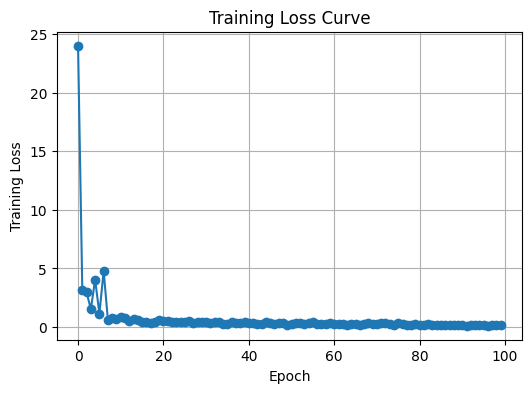

In [ ]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_mxene.parameters(), lr=pretrained_params['lr'])
batch_size = pretrained_params['batch_size']

epochs = 100
loss_list = []

for epoch in range(epochs):
    model_mxene.train()
    permutation = torch.randperm(X_trainval_t.size(0), generator=torch.Generator().manual_seed(SEED))

    epoch_loss = 0.0
    num_batches = 0

    for i in range(0, X_trainval_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_trainval_t[idx], y_trainval_t[idx]

        optimizer.zero_grad()
        outputs = model_mxene(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    loss_list.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# After training — plot loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


Best threshold for MXene model: 0.11
Confusion Matrix:
 [[7 1]
 [0 9]]
Classification Report:
               precision    recall  f1-score   support

         0.0     1.0000    0.8750    0.9333         8
         1.0     0.9000    1.0000    0.9474         9

    accuracy                         0.9412        17
   macro avg     0.9500    0.9375    0.9404        17
weighted avg     0.9471    0.9412    0.9408        17



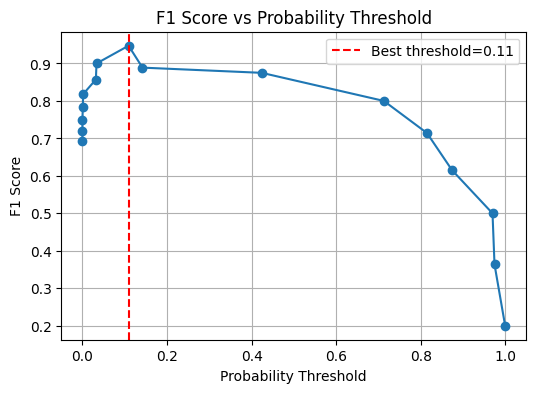


Best threshold for model outputs: 0.11
F1 score on test set: 0.9474


In [ ]:
# Evaluate on hold-out test set
model_mxene.eval()
with torch.no_grad():
    outputs = model_mxene(X_test_t).squeeze()
    probs_test = torch.sigmoid(outputs).cpu().numpy()
    y_true_test = y_test_t.cpu().numpy()

precisions, recalls, thresholds = precision_recall_curve(y_true_test, probs_test)

# drop the last element from precision and recall before computing F1
precisions, recalls = precisions[:-1], recalls[:-1]

f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold for MXene model: {best_threshold:.2f}")
y_pred = (probs_test >= best_threshold).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Best threshold={best_threshold:.2f}")
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Probability Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest threshold for model outputs: {best_threshold:.2f}")
print(f"F1 score on test set: {best_f1:.4f}")

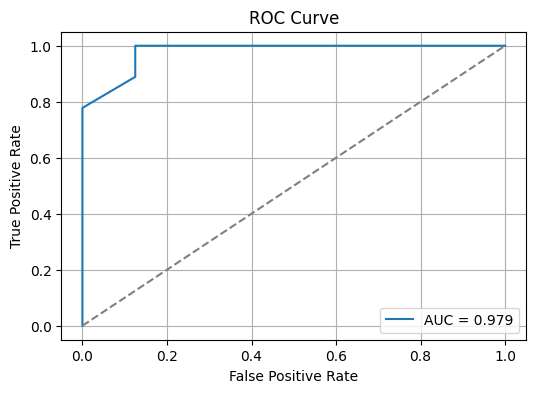

In [ ]:
# ROC curve

from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

fpr, tpr, roc_thresholds = roc_curve(y_true_test, probs_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

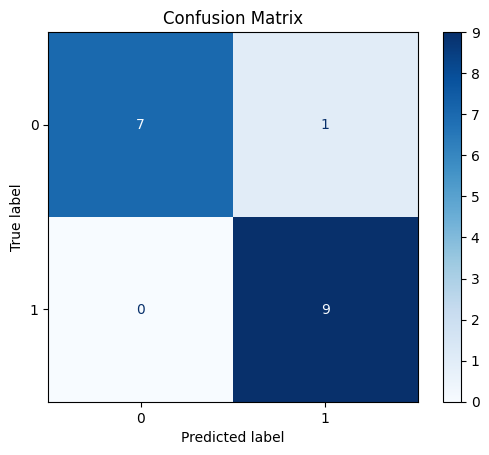

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
X_mx_solvent_p = mx_solvent_dataset.drop(columns=["label"])
y_mx_solvent_p = mx_solvent_dataset["label"]

X_mx_solvent_unlabeled_p = X_mx_solvent_p[y_mx_solvent_p == 0]


In [ ]:
X_mx_solvent_unlabeled_p.head()

,mx,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,plasmafrequency_x_1,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl
83,Ti3C2,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,455.7,760.0,N-methylformamide,True,False,False
84,Ti3C2,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,483.7,760.0,formamide,True,False,False
85,Ti3C2,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False
86,Ti3C2,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,334.3,760.0,chloroform,True,False,False
87,Ti3C2,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,1,353.9,760.0,cyclohexane,True,False,False


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipython-input-1155851623.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_mx_solvent_unlabeled['predicted_proba'] = proba_unlabeled
/tmp/ipython-input-1155851623.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_mx_solvent_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)


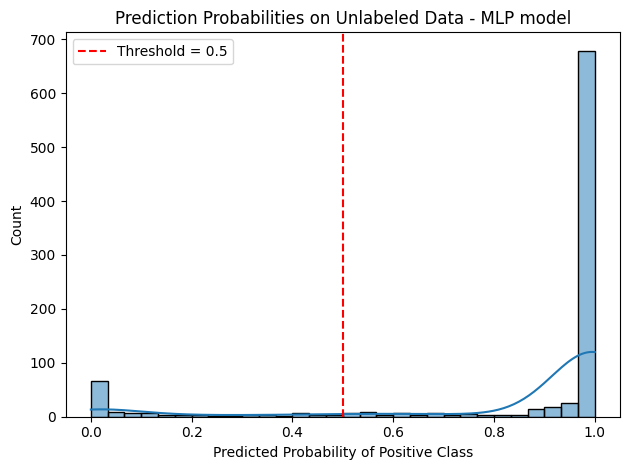

In [ ]:

with torch.no_grad():
    # Forward pass
    outputs = model_mxene(torch.tensor(X_mx_solvent_unlabeled_scaled, dtype=torch.float32))

    # If binary classification (single output neuron)
    proba_unlabeled = torch.sigmoid(outputs).cpu().numpy().flatten()

# Add to dataframe
X_mx_solvent_unlabeled['predicted_proba'] = proba_unlabeled
X_mx_solvent_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)

# Plot histogram
sns.histplot(proba_unlabeled, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on Unlabeled Data - MLP model")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
X_mx_solvent_unlabeled.head()

,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,plasmafrequency_x_1,plasmafrequency_y_1,dyn_stab_1,...,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label
83,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,455.7,760.0,1.0,0.0,0.0,0.970140,1
84,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,483.7,760.0,1.0,0.0,0.0,0.992996,1
85,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,463.2,760.0,1.0,0.0,0.0,0.000363,0
86,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,334.3,760.0,1.0,0.0,0.0,0.000172,0
87,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0.0,...,0.0,0.0,1.0,353.9,760.0,1.0,0.0,0.0,0.000032,0


In [ ]:
feature_names = x_unlabeled.columns
feature_names

Index(['mx', 'label', 'inchikey', 'gap_1', 'work_function_1',
       'formation_energy_1', 'ehull_1', 'alphax_el_1', 'alphay_el_1',
       'alphaz_el_1', 'plasmafrequency_x_1', 'plasmafrequency_y_1',
       'dyn_stab_1', 'has_inversion_symmetry_1', 'dE_zx_1', 'dE_zy_1', 'gap_2',
       'work_function_2', 'formation_energy_2', 'ehull_2', 'alphax_el_2',
       'alphay_el_2', 'alphaz_el_2', 'plasmafrequency_x_2',
       'plasmafrequency_y_2', 'dyn_stab_2', 'has_inversion_symmetry_2',
       'dE_zx_2', 'dE_zy_2', 'gap_3', 'work_function_3', 'formation_energy_3',
       'ehull_3', 'alphax_el_3', 'alphay_el_3', 'alphaz_el_3',
       'plasmafrequency_x_3', 'plasmafrequency_y_3', 'dyn_stab_3',
       'has_inversion_symmetry_3', 'dE_zx_3', 'dE_zy_3', 'delta_d', 'delta_p',
       'delta_h', 'molar_volume', 'molecular_weight', 'xlogp', 'charge',
       'tpsa', 'complexity', 'h_bond_donor_count', 'h_bond_acceptor_count',
       'rotatable_bond_count', 'heavy_atom_count', 'isotope_atom_count',
    

In [ ]:
X_mx_solvent_unlabeled.columns

Index(['gap_1', 'work_function_1', 'formation_energy_1', 'ehull_1',
       'alphax_el_1', 'alphay_el_1', 'alphaz_el_1', 'plasmafrequency_x_1',
       'plasmafrequency_y_1', 'dyn_stab_1', 'has_inversion_symmetry_1',
       'dE_zx_1', 'dE_zy_1', 'gap_2', 'work_function_2', 'formation_energy_2',
       'ehull_2', 'alphax_el_2', 'alphay_el_2', 'alphaz_el_2',
       'plasmafrequency_x_2', 'plasmafrequency_y_2', 'dyn_stab_2',
       'has_inversion_symmetry_2', 'dE_zx_2', 'dE_zy_2', 'gap_3',
       'work_function_3', 'formation_energy_3', 'ehull_3', 'alphax_el_3',
       'alphay_el_3', 'alphaz_el_3', 'plasmafrequency_x_3',
       'plasmafrequency_y_3', 'dyn_stab_3', 'has_inversion_symmetry_3',
       'dE_zx_3', 'dE_zy_3', 'delta_d', 'delta_p', 'delta_h', 'molar_volume',
       'molecular_weight', 'xlogp', 'charge', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'isotope_atom_count', 'atom_stereo_count',
       'bo

In [ ]:
unlabeled_proba_threshold = 0.5
high_confidence_pos_idx = np.where(proba_unlabeled > unlabeled_proba_threshold)[0]
print(f"Positive samples above threshold ({unlabeled_proba_threshold}) count: {len(high_confidence_pos_idx)}")

Positive samples above threshold (0.5) count: 790


In [ ]:
train_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/training/saved_models/"

In [ ]:
import pandas as pd

# Replace with your file path
file_path = f"{train_path}/005_mlp_2d_transfer_mx_prediction.csv"

# Load CSV into DataFrame
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Unnamed: 0,mx,inchikey,gap_1,work_function_1,formation_energy_1,ehull_1,alphax_el_1,alphay_el_1,alphaz_el_1,...,covalent_unit_count,boiling_point,mmhg,solvent,method_HF,method_LiCl/HF,method_LiF/HCl,predicted_proba,predicted_label,confidence_bin
0,83,Ti3C2,ATHHXGZTWNVVOU-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,455.7,760.0,N-methylformamide,True,False,False,0.970140,1,Extremely High (>0.9)
1,84,Ti3C2,ZHNUHDYFZUAESO-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,483.7,760.0,formamide,True,False,False,0.992996,1,Extremely High (>0.9)
2,85,Ti3C2,NNBZCPXTIHJBJL-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,463.2,760.0,"1,2,3,4,4a,5,6,7,8,8a-decahydronaphthalene",True,False,False,0.000363,0,Very Low (≤0.1)
3,86,Ti3C2,HEDRZPFGACZZDS-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,334.3,760.0,chloroform,True,False,False,0.000172,0,Very Low (≤0.1)
4,87,Ti3C2,XDTMQSROBMDMFD-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,1,353.9,760.0,cyclohexane,True,False,False,0.000032,0,Very Low (≤0.1)


In [ ]:
X_mx_solvent_unlabeled = X_mx_solvent_unlabeled.merge(x_unlabeled[["mx", "solvent"]], on="id", how="left")

KeyError: 'id'

In [ ]:
high_conf = X_mx_solvent_unlabeled[X_mx_solvent_unlabeled['predicted_proba'] >= 0.9]
high_conf = high_conf[high_conf['predicted_proba'] < 0.99]
top_list = high_conf.sort_values(by='predicted_proba', ascending=False)
print(top_list.shape)
top_list[['solvent', 'mx','predicted_proba', 'method_HF', 'method_LiCl/HF',
       'method_LiF/HCl']].head(10)

In [ ]:
print("\n=== Summary of predicted probabilities on unlabeled data ===")
print(X_mx_solvent_unlabeled['predicted_proba'].describe())

# Count how many samples fall into different confidence zones
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Very Low (≤0.1)', 'Low (0.1–0.3)', 'Mid (0.3–0.5)',
          'High (0.5–0.7)', 'Very High (0.7–0.9)', 'Extremely High (>0.9)']

X_mx_solvent_unlabeled['confidence_bin'] = pd.cut(X_mx_solvent_unlabeled['predicted_proba'], bins=bins, labels=labels, include_lowest=True)
print("\n=== Prediction count by confidence bin ===")
print(X_mx_solvent_unlabeled['confidence_bin'].value_counts().sort_index())

In [ ]:
X_mx_solvent_unlabeled.to_csv(f"{train_path}/005_mlp_2d_transfer_mx_prediction.csv")
X_mx_solvent_unlabeled.to_pickle(f"{train_path}/005__mlp_2d_transfer_mx_prediction.pkl")

In [ ]:
unwanted = ['mx', 'inchikey', 'solvent', 'predicted_proba', 'predicted_label', 'confidence_bin']   # replace with the names you don't want
feature_names = [f for f in feature_names if f not in unwanted]

print(feature_names)

In [ ]:
from sklearn.inspection import permutation_importance

first_layer_weights = model_mxene.fc1.weight.detach().cpu().numpy()

# Take mean absolute weight per input feature
importance = np.mean(np.abs(first_layer_weights), axis=0)

# Build dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature',
            data=feature_importance_df.head(10),
            palette='viridis')
plt.title('Feature Importance from MLP (weights)')
plt.tight_layout()
plt.show()

In [ ]:
mx_features = ['gap_1', 'work_function_1', 'formation_energy_1',
       'ehull_1', 'alphax_el_1', 'alphay_el_1', 'alphaz_el_1',
       'plasmafrequency_x_1', 'plasmafrequency_y_1', 'dyn_stab_1',
       'has_inversion_symmetry_1', 'dE_zx_1', 'dE_zy_1', 'gap_2',
       'work_function_2', 'formation_energy_2', 'ehull_2', 'alphax_el_2',
       'alphay_el_2', 'alphaz_el_2', 'plasmafrequency_x_2',
       'plasmafrequency_y_2', 'dyn_stab_2', 'has_inversion_symmetry_2',
       'dE_zx_2', 'dE_zy_2', 'gap_3', 'work_function_3', 'formation_energy_3',
       'ehull_3', 'alphax_el_3', 'alphay_el_3', 'alphaz_el_3',
       'plasmafrequency_x_3', 'plasmafrequency_y_3', 'dyn_stab_3',
       'has_inversion_symmetry_3', 'dE_zx_3', 'dE_zy_3']
solv_features = ['delta_d', 'delta_p',
       'delta_h', 'molar_volume', 'molecular_weight', 'xlogp', 'charge',
       'tpsa', 'complexity', 'h_bond_donor_count', 'h_bond_acceptor_count',
       'rotatable_bond_count', 'heavy_atom_count', 'isotope_atom_count',
       'atom_stereo_count', 'bond_stereo_count', 'covalent_unit_count',
       'boiling_point', 'mmhg', 'solvent', 'method_HF', 'method_LiCl/HF',
       'method_LiF/HCl']

In [ ]:
top_mx = feature_importance_df[feature_importance_df['feature'].isin(mx_features)] \
            .sort_values(by='importance', ascending=False) \
            .head(5)

# Top 5 from Solvent features
top_solv = feature_importance_df[feature_importance_df['feature'].isin(solv_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

# Display
print("Total  MXene Features:", len(mx_features))
print("Top 5 MXene Features:")
print(top_mx.to_string(index=False))

print("\nTotal  Solvent Features:", len(solv_features))
print("Top 5 Solvent Features:")
print(top_solv.to_string(index=False))

In [ ]:
df = df[df["predicted_proba"] <= 0.999]

In [ ]:
import pandas as pd

# Assuming df has columns: ['mx', 'solvent', 'probability']
top_solvents = (
    df.loc[df.groupby("mx")["predicted_proba"].idxmax(), ["mx", "solvent", "predicted_proba"]]
    .reset_index(drop=True)
)


In [ ]:
top_solvents

,mx,solvent,predicted_proba
0,Nb2C1,pyridine,0.998841
1,Ti3C2,2-(2-hydroxyethoxy)ethanol,0.998884
2,V2C1,decan-1-ol,0.998996
3,Zr3C2,formamide,0.998658
